# 농약 구조 패턴 찾기 — SMARTS 기초

## 학습 목표
- 지난 시간 `agro_score` 의 한계 이해 (카페인이 5점인 문제)
- **SMILES** 와 **SMARTS** 의 차이 이해
- RDKit 으로 분자에서 **부분구조(substructure)** 찾기
- 농약 데이터에서 **분자를 쪼개** 자주 나오는 **구조 조각**을 직접 발견하기

## 지난 시간 복습 — 왜 구조까지 봐야 하나
지난 `agro_score` 는 5개 물성(MW, logP, HBA, HBD, TPSA) 만으로 점수를 매겼다.

→ **카페인 5점**, **이부프로펜 5점** 이 나왔다 (둘 다 농약이 아님!)

**문제** — 분자량·극성 같은 "숫자"만으로는 농약과 의약품이 구별되지 않는다.

**해법** — 농약에는 **전형적인 구조 조각(fragment)** 이 있다.
이런 조각을 컴퓨터로 찾으려면 **SMARTS** 라는 패턴 언어가 필요하다.

## 오늘의 흐름 — 패턴은 어디서 오는가?
교과서/논문은 "농약에 자주 나오는 작용기" 를 미리 알려준다.
하지만 우리는 **데이터에서 직접** 찾아낸다 — 이것이 데이터과학적 접근.

1. **SMARTS 가 무엇인지** 먼저 익힌다 (1·2절).
2. **분자 하나를 쪼개** 핵심 골격(scaffold) 을 추출한다 (3절).
3. **3,000개 농약** 을 모두 쪼개 가장 자주 나오는 골격을 센다 (5절).
4. 그 골격을 **SMARTS 패턴** 으로 다시 사용해 농약다움의 신호를 검증한다 (6절).

## 기말고사 맥락
1. **이번 시간**: 농약 데이터에서 흔한 골격을 직접 찾아내기
2. 다음 시간: 비농약(의약품) 데이터의 같은 패턴 빈도와 비교 → 점수 검증
3. 그 다음: 결과를 `agro_score` 에 합쳐 더 똑똑한 점수 만들기

## 1. SMILES vs SMARTS

| | 용도 | 예시 |
|---|---|---|
| **SMILES** | 한 분자를 **표현**하는 문자열 | `Clc1ccccc1` (= 클로로벤젠 SMILES 코드) |
| **SMARTS** | 분자에서 찾을 **패턴**을 표현하는 문자열 | `'[#17]-[#6](-[#17])(-[#17])-[#6](-[#6]1:[#6]:[#6]:[#6](-[#17]):[#6]:[#6]:1)-[#6]1:[#6]:[#6]:[#6](-[#17]):[#6]:[#6]:1'` (= 클로로벤젠의 SMARTS 패턴) |

SMARTS 는 SMILES 의 **확장판**.
- 거의 모든 SMILES 는 SMARTS 로도 동작한다.
- 추가로 와일드카드, 원자 조건 등을 쓸 수 있다 (오늘은 단순한 형태만).

### RDKit 함수 두 개
| 함수 | 입력 | 출력 |
|---|---|---|
| `Chem.MolFromSmiles(smi)` | SMILES 문자열 | **분자 객체** |
| `Chem.MolFromSmarts(smt)` | SMARTS 문자열 | **패턴 객체** |

그리고 "분자에 패턴이 있나?" 를 물어보는 함수:
- `mol.HasSubstructMatch(pattern)` → `True` / `False`

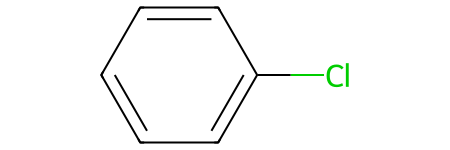

In [30]:
from rdkit import Chem, RDLogger
RDLogger.DisableLog('rdApp.*')   # 경고 메시지 끄기

# 분자 만들기 — 클로로벤젠 (벤젠에 Cl 하나 붙은 분자)
mol = Chem.MolFromSmiles('Clc1ccccc1')
mol

In [31]:
Chem.MolToSmarts(mol) #rdkit mol을 smarts 패턴으로 전환

'[#17]-[#6]1:[#6]:[#6]:[#6]:[#6]:[#6]:1'

In [32]:
pattern = Chem.MolFromSmarts('Cl')

In [33]:
# 분자 안에 패턴이 있으면 True, 없으면 False
print('클로로벤젠에 Cl?', mol.HasSubstructMatch(pattern))

# 다른 분자로 — 메탄 (CH4): Cl 없음
mol2 = Chem.MolFromSmiles('C')
print('메탄에 Cl?     ', mol2.HasSubstructMatch(pattern))

# 예상 출력:
# 클로로벤젠에 Cl? True
# 메탄에 Cl?      False

클로로벤젠에 Cl? True
메탄에 Cl?      False


## 2. 매칭 개수 세기 — `GetSubstructMatches`

`HasSubstructMatch` 는 **있다/없다**(True/False) 만 알려준다.
`GetSubstructMatches` 는 **몇 번 나오는지** 까지 알려준다.

- 결과는 **튜플들의 튜플** — 안쪽 튜플 하나가 매칭된 위치(원자 번호)
- 결과가 비어 있으면 `()` → 0개
- 개수만 알고 싶으면 `len(...)` 사용

In [34]:
# 분자: DDT (살충제) — Cl 5개 (CCl3 + 두 벤젠 고리에 Cl 하나씩)
mol = Chem.MolFromSmiles('ClC(Cl)(Cl)C(c1ccc(Cl)cc1)c1ccc(Cl)cc1')
pattern = Chem.MolFromSmarts('Cl')

# 모든 매치 위치 찾기
matches = mol.GetSubstructMatches(pattern)

print('매치 결과 (튜플들의 튜플):')
print(matches)
print()
print('Cl 개수:', len(matches))

# 예상 출력:
# 매치 결과 (튜플들의 튜플):
# ((0,), (2,), (3,), (9,), (16,))    ← 안쪽 숫자는 RDKit 내부 원자 번호
#
# Cl 개수: 5

매치 결과 (튜플들의 튜플):
((0,), (2,), (3,), (9,), (16,))

Cl 개수: 5


## 3. 패턴은 어디서 오는가? — 분자 쪼개기

지금까지는 **사람이 미리 알고 있는 패턴** (`Cl`) 을 분자에 들이밀었다.
이제 방향을 거꾸로 — **분자에서 패턴을 뽑아낸다**.

### 핵심 아이디어 — Murcko 스캐폴드
분자는 보통 **고리 골격(scaffold) + 곁사슬(side chain)** 으로 이루어진다.

```
       곁사슬                   곁사슬
         │                       │
    [ ━━ 고리 골격 ━━ 다리 ━━ 고리 골격 ━━ ]
         │                       │
       곁사슬                   곁사슬
```

**Murcko 스캐폴드** = 곁사슬을 떼어 내고 **고리 + 고리를 잇는 다리** 만 남긴 것.
→ "이 분자의 핵심 골격" 을 한 줄짜리 SMILES 로 뽑아낼 수 있다.

### RDKit 한 줄
```python
from rdkit.Chem.Scaffolds import MurckoScaffold
scaffold = MurckoScaffold.GetScaffoldForMol(mol)
```

결과는 다시 **분자 객체** — `Chem.MolToSmiles(scaffold)` 로 문자열로 만들 수 있다.
그리고 그 문자열은 그대로 **SMARTS 패턴** 으로도 사용 가능 (1절 표 참고).

원본       : CCNc1nc(Cl)nc(NC(C)C)n1


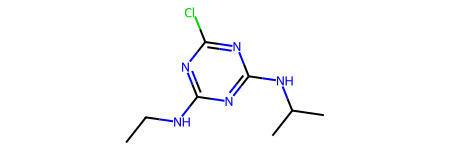

In [35]:
from rdkit.Chem.Scaffolds import MurckoScaffold

# 예시 1 — 아트라진 (제초제)
# 곁사슬 두 개(에틸아미노, 이소프로필아미노) + Cl 하나가 트리아진 고리에 붙어있음
mol = Chem.MolFromSmiles('CCNc1nc(Cl)nc(NC(C)C)n1')
print('원본       :', Chem.MolToSmiles(mol))
mol

Murcko 골격: c1ncncn1

→ 곁사슬과 Cl 가 모두 사라지고 "트리아진 고리" 만 남는다.


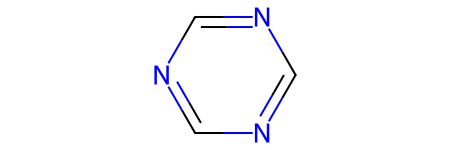

In [36]:
# 스캐폴드 추출 — 곁사슬 다 떼고 고리만 남김
scaffold = MurckoScaffold.GetScaffoldForMol(mol)
scaffold_smi = Chem.MolToSmiles(scaffold)

print('Murcko 골격:', scaffold_smi)
print()
print('→ 곁사슬과 Cl 가 모두 사라지고 "트리아진 고리" 만 남는다.')
scaffold   # 그림으로 표시

# 예상 출력:
# 원본       : CCNc1nc(Cl)nc(NC(C)C)n1
# Murcko 골격: c1ncncn1
#
# → 곁사슬과 Cl 가 모두 사라지고 "트리아진 고리" 만 남는다.

원본       : Clc1ccc(C(c2ccc(Cl)cc2)C(Cl)(Cl)Cl)cc1


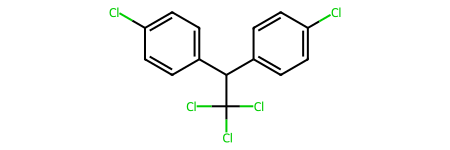

In [37]:
# 예시 2 — DDT (살충제)
# CCl3 와 벤젠의 Cl 들이 다 떨어지고, "벤젠-CH-벤젠" 다리 구조만 남음
mol = Chem.MolFromSmiles('ClC(Cl)(Cl)C(c1ccc(Cl)cc1)c1ccc(Cl)cc1')
print('원본       :', Chem.MolToSmiles(mol))
mol

DDT 골격: c1ccc(Cc2ccccc2)cc1


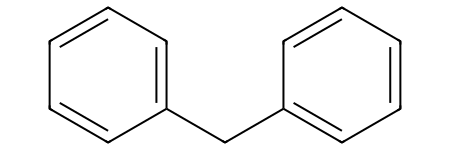

In [38]:


scaffold = MurckoScaffold.GetScaffoldForMol(mol)
print('DDT 골격:', Chem.MolToSmiles(scaffold))
scaffold

# 예상 출력:
# DDT 골격: c1ccc(Cc2ccccc2)cc1
#
# → 두 벤젠 고리가 CH 다리로 연결된 모양만 남는다.
#   (Cl 들은 곁사슬 취급되어 제거됨)

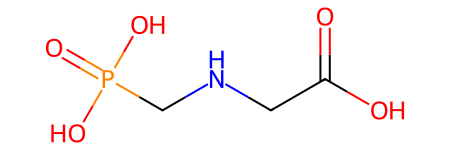

In [39]:
# 주의 — 고리가 없는 분자는 빈 스캐폴드 ('')
# 예: 글리포세이트 (제초제) — 고리 없음
mol = Chem.MolFromSmiles('OC(=O)CNCP(=O)(O)O')
mol

글리포세이트 골격: ''
→ 빈 문자열이 나오는 이유: Murcko 는 "고리" 기반 골격이라
  고리가 없는 분자는 결과가 비어 있다. 나중에 빈 결과는 건너뛴다.


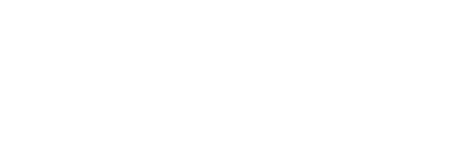

In [40]:
scaffold = MurckoScaffold.GetScaffoldForMol(mol)

print('글리포세이트 골격:', repr(Chem.MolToSmiles(scaffold)))
print('→ 빈 문자열이 나오는 이유: Murcko 는 "고리" 기반 골격이라\n  고리가 없는 분자는 결과가 비어 있다. 나중에 빈 결과는 건너뛴다.')
scaffold
# 예상 출력:
# 글리포세이트 골격: ''
# → 빈 문자열이 나오는 이유: Murcko 는 "고리" 기반 골격이라
#   고리가 없는 분자는 결과가 비어 있다. 나중에 빈 결과는 건너뛴다.

## 4. 농약 데이터 불러오기

PubChem 농약 데이터(약 3,000개) 를 불러온다.
이번엔 CSV 의 **`smiles` 칼럼** (분자 구조 문자열) 을 사용한다.

In [41]:
import pandas as pd

df = pd.read_csv('PubChem_Agrochemical.csv')

# 사용할 칼럼: 이름과 SMILES
df = df[['cmpdname', 'smiles']].dropna()
print('농약 분자 수:', len(df))
df.head(3)

# 예상 출력:
# 농약 분자 수: 3098

농약 분자 수: 3098


,cmpdname,smiles
0,"1,2-Dichloroethane",C(CCl)Cl
1,Tartronic acid,C(C(=O)O)(C(=O)O)O
2,3-Hydroxybenzaldehyde,C1=CC(=CC(=C1)O)C=O


## 5. 모든 분자를 쪼개 — 흔한 골격 찾기 (완성 예시)

### 알고리즘
```
빈 카운터 만들기
for 각 분자:
    SMILES → 분자 객체
    분자에서 Murcko 골격 추출
    골격을 SMILES 문자열로 변환
    빈 골격이면 건너뛰기
    카운터[골격] += 1
가장 많이 나온 상위 N개 출력
```

### `Counter` — 빈도 세기 도구
`collections.Counter` 는 "같은 문자열이 몇 번 나왔나" 를 세는 사전.
- `c[key] += 1` 로 카운트 증가
- `c.most_common(N)` 으로 상위 N개를 (key, count) 쌍의 리스트로 반환

In [42]:
from collections import Counter

scaffold_counter = Counter()    # 골격 → 출현 횟수

for smi in df['smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:                                       # 파싱 실패 → 건너뛰기
        continue
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    scaffold_smi = Chem.MolToSmiles(scaffold)
    if scaffold_smi == '':                                # 고리 없는 분자 → 건너뛰기
        continue
    scaffold_counter[scaffold_smi] = scaffold_counter[scaffold_smi] + 1

print('=== 가장 많이 나온 골격 Top 10 ===')
for scaffold_smi, count in scaffold_counter.most_common(10):
    print(f'{count:>4}회 : {scaffold_smi}')

# 예상 출력 (대략적인 모습 — 정확한 순위는 데이터에 따라 다름):
#   ???회 : c1ccccc1                  ← 벤젠
#   ???회 : c1ccncc1                  ← 피리딘
#   ???회 : c1ncncn1                  ← 트리아진
#   ???회 : c1ccc(-c2ccccc2)cc1       ← 비페닐
#   ???회 : c1ccc(Cc2ccccc2)cc1       ← DDT 류
#   ...

=== 가장 많이 나온 골격 Top 10 ===
 584회 : c1ccccc1
  59회 : c1ccncc1
  44회 : c1ccc(Oc2ccccc2)cc1
  36회 : c1ncncn1
  36회 : O=C(OCc1cccc(Oc2ccccc2)c1)C1CC1
  24회 : c1ccc2ccccc2c1
  21회 : c1nc[nH]n1
  21회 : O=C1C=CCCC1
  20회 : c1ccsc1
  18회 : c1cncnc1


## 6. 발견한 골격을 SMARTS 패턴으로 — 검증

5절에서 찾은 상위 골격은 **분자 전체와 똑같이** 일치하는 분자만 확인.
(예: 벤젠 골격 → 벤젠 고리만 있는 분자)

이번에는 그 골격 문자열을 **SMARTS 패턴** 으로 사용해
**"부분구조로 포함"** 하는 분자까지 모두 센다.
→ 같은 벤젠 고리라도 곁사슬이 달라도 매치된다.

**즉** — 5절은 정확히 같은 골격, 6절은 그 골격을 **품고 있는** 모든 분자.

In [43]:
# 상위 5개 골격을 하나씩 SMARTS 패턴으로 만들어 데이터셋에 부분구조 매칭
print(f'{"골격":<32} {"포함 분자":>10} {"비율":>8}')
print('-' * 54)

for scaffold_smi, _ in scaffold_counter.most_common(5):
    pattern = Chem.MolFromSmarts(scaffold_smi)
    count = 0
    total = 0
    for smi in df['smiles']:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        total = total + 1
        if mol.HasSubstructMatch(pattern):
            count = count + 1
    ratio = count / total * 100
    print(f'{scaffold_smi:<32} {count:>10} {ratio:>7.1f}%')

# → \"정확히 그 골격\" 보다 \"그 골격을 포함\" 하는 분자가 훨씬 많다.
#   예: 벤젠 c1ccccc1 의 경우 5절은 100~200 개지만
#   6절에서는 데이터의 50% 이상이 벤젠 고리를 \"포함\" 할 수 있다.

골격                                    포함 분자       비율
------------------------------------------------------
c1ccccc1                               1720    55.5%
c1ccncc1                                256     8.3%
c1ccc(Oc2ccccc2)cc1                     110     3.6%
c1ncncn1                                102     3.3%
O=C(OCc1cccc(Oc2ccccc2)c1)C1CC1          36     1.2%


## 7. 거꾸로 — 골격을 빼고 **잔기(residue)** 만 모으기

5절은 분자에서 **골격(고리)** 을 남겼다. 이번엔 **반대로** — 골격을 **빼고**
남는 부분(곁사슬, 잔기) 을 모은다. 그러면 자연스럽게 **\"농약 작용기\"** 가 발견된다.

### 핵심 함수 두 개
| 함수 | 설명 |
|---|---|
| `Chem.ReplaceCore(mol, scaffold)` | 분자에서 골격을 빼고 곁사슬만 남김. 붙어 있던 자리는 `[1*]`, `[2*]` ... 로 표시 |
| `Chem.GetMolFrags(mol, asMols=True)` | 한 객체에 들어 있는 여러 조각(`.` 으로 연결) 을 분리해 분자 리스트로 |

### 부착점 번호 통일
잔기 SMILES 의 `[1*]`, `[2*]`, ... 는 분자마다 번호가 다르다.
같은 \"Cl 잔기\" 라도 어떤 분자에서는 `[1*]Cl`, 다른 분자에서는 `[2*]Cl` 로 나온다.
이걸 합치려면 모든 번호를 `[*]` 로 바꿔야 하고 — 단순히 `replace` 를 반복문으로 돌리면 된다.

### 오늘의 발견
이렇게 자동 추출된 잔기 상위에는 **`[*]Cl`, `[*]C`, `[*]N`, `[*]C(F)(F)F`** 같은
조각들이 등장한다. 교과서가 \"농약 작용기\" 라고 정해 둔 **CF₃ · 할로겐 · 아미노기** 가
**우리가 데이터에서 직접 발견** 한 것이다.

In [44]:
# (Counter, MurckoScaffold, df 는 위에서 이미 임포트·로드)

# --- (a) 단일 분자 시연 — 아트라진 ---
mol = Chem.MolFromSmiles('CCNc1nc(Cl)nc(NC(C)C)n1')
scaffold = MurckoScaffold.GetScaffoldForMol(mol)
sidechains = Chem.ReplaceCore(mol, scaffold)

print('아트라진 잔기:', Chem.MolToSmiles(sidechains))
for frag in Chem.GetMolFrags(sidechains, asMols=True):
    print('  ', Chem.MolToSmiles(frag))

# --- (b) 데이터 전체에서 잔기 모으기 ---
residue_counter = Counter()

for smi in df['smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    sidechains = Chem.ReplaceCore(mol, scaffold)
    if sidechains is None:
        continue
    for frag in Chem.GetMolFrags(sidechains, asMols=True):
        key = Chem.MolToSmiles(frag)
        # 부착점 번호 [1*], [2*], ... 를 모두 [*] 로 통일
        for n in range(1, 10):
            key = key.replace(f'[{n}*]', '[*]')
        residue_counter[key] = residue_counter[key] + 1

print()
print('=== 가장 흔한 잔기 Top 15 ===')
for residue_smi, count in residue_counter.most_common(15):
    print(f'{count:>5}회 : {residue_smi}')

# --- (c) 잔기는 그대로 SMARTS 패턴 — 가장 흔한 잔기로 검증 ---
top_smi = residue_counter.most_common(1)[0][0]
pattern = Chem.MolFromSmarts(top_smi)
count = 0
for smi in df['smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None and mol.HasSubstructMatch(pattern):
        count = count + 1
print()
print(f'{top_smi} 를 가진 분자: {count} 개')

# → 외워야 했던 \"농약 작용기 표\" 가 데이터에서 자동 발견됐다.

아트라진 잔기: [1*]NCC.[2*]Cl.[3*]NC(C)C
   [1*]NCC
   [2*]Cl
   [3*]NC(C)C

=== 가장 흔한 잔기 Top 15 ===
 1630회 : [*]C
 1545회 : [*]Cl
  786회 : [*]O
  368회 : [*]OC
  292회 : [*]F
  233회 : [*]C(=O)O
  232회 : [*]C(F)(F)F
  169회 : [*]N
  147회 : [*][N+](=O)[O-]
  135회 : [*]C#N
  103회 : [*]CC
   76회 : [*]C(C)C
   73회 : [*]C(=O)OC
   72회 : [*]Br
   72회 : [*]C(C)(C)C

[*]C 를 가진 분자: 2842 개


# QED 함수에서 사용되는 alerts 패턴 출력 방법
#### https://www.rdkit.org/docs/source/rdkit.Chem.QED.html
1. QED 함수도 smarts 패턴을 기반으로 분자 패턴을 찾는 기능이 있음 (alert).
2. QED.py 파일 내에 smarts 패턴들이 기재되어 있음.

In [58]:
from rdkit.Chem import QED
import inspect

# 1. 모듈 내 정의 확인
print('QED 계산 소스 파일:', inspect.getsourcefile(QED))
# → .../rdkit/Chem/QED.py 경로 출력

# 2. SMARTS 리스트 직접 접근
print('QED alert patterns:',len(QED.StructuralAlerts))           # 패턴 개수
for i, patt in enumerate(QED.StructuralAlerts[:5]):
    print(i, Chem.MolToSmarts(patt))          # 처음 5개 출력

# 3. 원본 SMARTS 문자열
print(QED.AcceptorSmarts) # Hydrogen Bond Acceptor 개수를 확인할 때 사용하는 SMARTS 패턴

# SMARTS 패턴 전체 출력 방법: StructuralAlertSmarts 
# 변수명은 버전마다 다를 수 있으므로 dir(QED)로 확인
print([n for n in dir(QED) if 'alert' in n.lower()])

QED 계산 소스 파일: C:\Users\user\miniconda3\Lib\site-packages\rdkit\Chem\QED.py
QED alert patterns: 116
0 *1[O,S,N]*1
1 [S,C](=[O,S])[F,Br,Cl,I]
2 [C&X4][Cl,Br,I]
3 [#6]S(=O)(=O)O[#6]
4 [$([C&H1]),$(CC)]#CC(=O)[#6]
['[oH0;X2]', '[OH1;X2;v2]', '[OH0;X2;v2]', '[OH0;X1;v2]', '[O-;X1]', '[SH0;X2;v2]', '[SH0;X1;v2]', '[S-;X1]', '[nH0;X2]', '[NH0;X1;v3]', '[$([N;+0;X3;v3]);!$(N[C,S]=O)]']
['StructuralAlertSmarts', 'StructuralAlerts']


## 정리

### 오늘 배운 것
- **SMILES** = 분자 표현, **SMARTS** = 패턴 표현
- `Chem.MolFromSmarts(...)` → 패턴 객체 생성
- `mol.HasSubstructMatch(patt)` → True/False
- `mol.GetSubstructMatches(patt)` → 매치 위치 튜플 (개수는 `len(...)`)
- `MurckoScaffold.GetScaffoldForMol(mol)` → 곁사슬을 떼고 **고리 골격만** 뽑기
- `Counter` 로 농약 데이터 전체에서 자주 나오는 골격 찾기
- 발견한 골격을 다시 SMARTS 패턴으로 사용해 검증

### 핵심 통찰
| 접근 | 패턴의 출처 |
|---|---|
| 교과서식 | 사람이 미리 안다 (CF₃, P=O 등) |
| **데이터 기반(오늘)** | **분자를 쪼개 데이터가 알려주게 한다** |

→ 오늘 우리는 "농약에 무슨 골격이 있더라?" 를 외우지 않고,
  3,000개 분자를 쪼개 컴퓨터가 직접 찾도록 했다.

## 추가 실험 과제 (선택)

1. 농약에 있는 모든 골격 (scaffold) 확인하기
2. **다른 쪼개기 — BRICS** — `from rdkit.Chem import BRICS` 후 `BRICS.BRICSDecompose(mol)` 로 분자를 여러 조각으로 쪼개 가장 흔한 조각을 세보자 (Murcko 와 결과가 어떻게 다른가?).
3. 다른 물질 군과 비교해보기 (예: 의약품)